# Orienteering Problem: Exhaustive · MILP · ALNS

Solves the **Orienteering Problem (OP)** on the 6-cell benchmark scenario:
select a subset of cells, choose visit order, and optimise per-cell survey parameters
subject to a total flight budget.

## Objective function

$$\max_{S,\,\sigma} \sum_{k \in S} f_k \quad
  \text{s.t.}\quad
  \sum_{k \in S} d_k^{\text{survey}} + \sum_{\text{transit}} T_{ij} \leq B$$

- $f_k = w_k$ (circular, fixed)
- $f_k = w_k \cdot \frac{\text{CovArea}(n,s) + 0.5\cdot\text{OvlpArea}(n,s)}{\pi ab}$ (elliptical)
- Budget $B$ is set to the midpoint between the minimum 4-cell and 5-cell tour costs,
  forcing a non-trivial selection among all 6 cells.

## Algorithms

| Algorithm | Guarantee | Backend |
|-----------|-----------|---------|
| Exhaustive enumeration | **Global optimum** ✓ | Python (N=6 only) |
| MILP (MTZ subtour elimination) | **Global optimum** ✓ | scipy / HiGHS |
| ALNS (greedy init, 5 seeds × 500 iters) | Local optimum | Adaptive heuristic |
| ALNS (random init, 10 seeds × 1000 iters) | Local optimum | Adaptive heuristic |

Run `00_simulation_data.ipynb` first.


In [1]:
import numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches
import time, itertools
from dataclasses import dataclass, field
from typing import List, Optional
from math import cos, sin, sqrt, pi, radians, degrees
from scipy.optimize import milp as sp_milp, LinearConstraint, Bounds
from scipy.sparse import csr_matrix

np.set_printoptions(precision=3, suppress=True)

# ── Geometry utilities ────────────────────────────────────────────────────
def uvec(a): return np.array([cos(a), sin(a)])
def rot2d(a):
    c,s=cos(a),sin(a); return np.array([[c,-s],[s,c]])
def cross2d(v,w): return float(v[0]*w[1]-v[1]*w[0])
def ensure_ccw(verts):
    pts=[np.asarray(v,float) for v in verts]
    area2=sum(pts[i][0]*pts[(i+1)%len(pts)][1]-pts[(i+1)%len(pts)][0]*pts[i][1]
              for i in range(len(pts)))
    return pts if area2>0 else pts[::-1]
def segments_intersect(p1,p2,p3,p4):
    EPS=1e-9; d1,d2=p2-p1,p4-p3; denom=cross2d(d1,d2)
    if abs(denom)<EPS: return False
    diff=p3-p1; t=cross2d(diff,d2)/denom; u=cross2d(diff,d1)/denom
    return EPS<t<1-EPS and EPS<u<1-EPS
def point_in_poly(pt,verts):
    EPS=1e-9
    for i in range(len(verts)):
        if cross2d(verts[(i+1)%len(verts)]-verts[i],pt-verts[i])<=EPS: return False
    return True
def seg_blocked(p1,p2,verts):
    for i in range(len(verts)):
        if segments_intersect(p1,p2,verts[i],verts[(i+1)%len(verts)]): return True
    return point_in_poly(0.5*(p1+p2),verts)
def path_len(w): return sum(np.linalg.norm(w[i+1]-w[i]) for i in range(len(w)-1))
def obs_free(start,end,verts):
    s,e=np.asarray(start,float),np.asarray(end,float)
    verts=[np.asarray(v,float) for v in verts]
    ok=lambda a,b: not seg_blocked(a,b,verts)
    if ok(s,e): return [s,e]
    n=len(verts); best,bd=None,float('inf')
    for v in verts:
        if ok(s,v) and ok(v,e):
            d=np.linalg.norm(v-s)+np.linalg.norm(e-v)
            if d<bd: bd,best=d,[s,v,e]
    for si in range(n):
        for ln in range(1,n):
            for arc in [[verts[(si+k)%n] for k in range(ln+1)],
                        [verts[(si-k)%n] for k in range(ln+1)]]:
                c=[s]+arc+[e]
                if all(ok(c[k],c[k+1]) for k in range(len(c)-1)):
                    d=path_len(c)
                    if d<bd: bd,best=d,c
    return best or [s,e]
def multi_obs(start,end,obstacles):
    if not obstacles: return [np.asarray(start,float),np.asarray(end,float)]
    cur=[np.asarray(start,float),np.asarray(end,float)]
    for obs in obstacles:
        obs=[np.asarray(v,float) for v in obs]; nw=[cur[0]]
        for i in range(len(cur)-1): nw.extend(obs_free(cur[i],cur[i+1],obs)[1:])
        cur=nw
    return cur
def transit_dist(p, q, obstacles):
    return path_len(multi_obs(p, q, obstacles))
print('Geometry utilities loaded.')


Geometry utilities loaded.


In [2]:
@dataclass
class CircularSupercell:
    center:np.ndarray; radius:float; L_max:float; weight:float; name:str
    sensitivity_points:List[np.ndarray]=field(default_factory=list)
    obstacle:Optional[List[np.ndarray]]=None
    def __post_init__(self):
        self.center=np.asarray(self.center,float)
        self.sensitivity_points=[np.asarray(s,float) for s in self.sensitivity_points]
        if self.obstacle is not None:
            self.obstacle=ensure_ccw([np.asarray(v,float) for v in self.obstacle])
    def cross_endpoints(self,theta,L):
        u1,u2=uvec(theta),uvec(theta+pi/2)
        return self.center-L*u1,self.center+L*u1,self.center-L*u2,self.center+L*u2
    def cross_blocked(self,theta,L):
        if self.obstacle is None: return False
        P0,P1,P2,P3=self.cross_endpoints(theta,L); c=self.center
        return any(seg_blocked(c,p,self.obstacle) for p in [P0,P1,P2,P3])

@dataclass
class EllipticalSupercell:
    center:np.ndarray; a:float; b:float; phi:float; weight:float; name:str
    obstacle:Optional[List[np.ndarray]]=None
    def __post_init__(self):
        self.center=np.asarray(self.center,float); self._R=rot2d(self.phi)
        if self.obstacle is not None:
            self.obstacle=ensure_ccw([np.asarray(v,float) for v in self.obstacle])
    def to_world(self,e): return self.center+self._R@np.asarray(e,float)
    def leg_halflen(self,xp,dt):
        if abs(xp)>=self.a: return None
        return self.b*sqrt(max(0.,1.-(xp/self.a)**2))+dt
    def leg_endpoints(self,xp,dt):
        L=self.leg_halflen(xp,dt)
        if L is None: return None
        return self.to_world(np.array([xp,-L])),self.to_world(np.array([xp,L]))
    def leg_positions(self,n,s): return [-(n-1)*s/2.+i*s for i in range(n)]
    def legs_valid(self,n,s): return all(abs(xp)<self.a for xp in self.leg_positions(n,s))

def compute_coverage(cell,xps,sw,gr=2.,ob=0.5):
    xa=np.arange(-cell.a-gr,cell.a+gr+0.1,gr); ya=np.arange(-cell.b-gr,cell.b+gr+0.1,gr)
    XX,YY=np.meshgrid(xa,ya); ins=(XX/cell.a)**2+(YY/cell.b)**2<=1.
    xp=np.array(xps,float); dx=np.abs(XX[:,:,None]-xp[None,None,:]); cov=(dx<=sw).sum(axis=2)
    ca=gr**2; cv=float((ins&(cov>=1)).sum()*ca); ov=float((ins*np.maximum(0,cov-1)).sum()*ca)
    return cv,ov
print('Dataclasses and coverage loaded.')


Dataclasses and coverage loaded.


In [3]:
def route_circ_from(start, cell, theta, L, all_obs):
    """Optimal ordering: cross arms and sensitivity points in any order/direction.
    Returns (dist, exit_pt)."""
    s = np.asarray(start, float)
    P0, P1, P2, P3 = cell.cross_endpoints(theta, L)
    c = np.asarray(cell.center, float)
    # Each task: list of (entry, [internal_wpts], exit) options
    # Arms reversible; sensitivity points have a single option
    arm1 = [(P0, [c, P1], P1), (P1, [c, P0], P0)]
    arm2 = [(P2, [c, P3], P3), (P3, [c, P2], P2)]
    task_opts = [arm1, arm2] + [[(sp, [], sp)] for sp in cell.sensitivity_points]
    n = len(task_opts)
    best_d, best_pos = float('inf'), s
    for perm in itertools.permutations(range(n)):
        for choices in itertools.product(*[task_opts[i] for i in perm]):
            pos = s.copy(); d = 0.
            for (entry, wpts, exit_pt) in choices:
                entry = np.asarray(entry, float)
                tr = multi_obs(pos, entry, all_obs); d += path_len(tr); pos = entry
                for wp in wpts:
                    wp = np.asarray(wp, float); d += np.linalg.norm(wp - pos); pos = wp
                pos = np.asarray(exit_pt, float)
            if d < best_d: best_d, best_pos = d, pos.copy()
    return best_d, best_pos

def route_ellip_from(start, cell, n, s, dt, rev, etop, all_obs):
    """Boustrophedon scan from start. Returns (dist, exit_pt)."""
    s_=np.asarray(start,float)
    ordered=list(reversed(cell.leg_positions(n,s))) if rev else cell.leg_positions(n,s)
    legs=[]
    for xp in ordered:
        ep=cell.leg_endpoints(xp,dt)
        if ep is None: return float('inf'),s_
        legs.append(ep)
    dist=0.; pos=s_.copy()
    for i,(bot,top) in enumerate(legs):
        gu=(i%2==0)!=etop; ep_,ex=(bot,top) if gu else (top,bot)
        tr=multi_obs(pos,ep_,all_obs); dist+=path_len(tr); pos=tr[-1]
        dist+=np.linalg.norm(ex-pos); pos=ex.copy()
    return dist,pos

def precompute_cell(cell, all_obs, start_pt,
                    theta_grid, L_grid, sw, dt, s_min, n_max, n_s_steps,
                    overlap_bonus=0.5):
    """Enumerate all survey configurations. Returns list of dicts."""
    configs = []
    if isinstance(cell, CircularSupercell):
        for theta in theta_grid:
            for L in L_grid:
                if L > cell.L_max: continue
                if cell.cross_blocked(theta, L): continue
                d, exit_pt = route_circ_from(start_pt, cell, theta, L, all_obs)
                if d < float('inf'):
                    configs.append(dict(score=cell.weight, survey_dist=d, exit_pt=exit_pt,
                                        params=dict(theta=theta, L=L), cell_type='circ'))
    else:
        ellip_ref = pi * cell.a * cell.b
        for n in range(1, n_max+1):
            sl = ([0.] if n == 1
                  else ([] if 2.*cell.a/(n-1)*0.999 < s_min
                        else list(np.linspace(s_min, 2.*cell.a/(n-1)*0.999, n_s_steps))))
            for s in sl:
                if not cell.legs_valid(n, s): continue
                xps = cell.leg_positions(n, s)
                cv, ov = compute_coverage(cell, xps, sw)
                sc = cell.weight * (cv + overlap_bonus * ov) / ellip_ref
                for rev in [False, True]:
                    for etop in [False, True]:
                        d, exit_pt = route_ellip_from(start_pt, cell, n, s, dt, rev, etop, all_obs)
                        if d < float('inf'):
                            configs.append(dict(score=sc, survey_dist=d, exit_pt=exit_pt,
                                                params=dict(n=n, s=float(s), rev=rev, etop=etop),
                                                cell_type='ellip'))
    return configs
print('Survey route helpers loaded.')


Survey route helpers loaded.


In [4]:
# ── Load scenario from pickle ─────────────────────────────────────────────
import pickle
with open('data/scenario_N6_seed42.pkl', 'rb') as f:
    s = pickle.load(f)
BASE        = s['BASE']
OBSTACLES   = s['OBSTACLES']
ALL_CELLS   = s['cells']
labels      = s['labels']
N_CELLS     = s['N_CELLS']
valid_cells = list(range(1, N_CELLS+1))

# Survey parameter grids
THETA_GRID = np.radians(np.arange(0, 180, 15))
L_GRID     = np.array([35., 50., 65., 80.])
SW=12.; DT=8.; S_MIN=18.; N_MAX=6; N_S_STEPS=10; OVERLAP_BONUS=0.5

print(f'Loaded scenario: {N_CELLS} cells, {len(OBSTACLES)} obstacles, BASE={BASE}')
print()
print(f"  {'Cell':>4}  {'Type':>10}  {'Weight':>6}  {'Center'}")
for k, cell in enumerate(ALL_CELLS):
    ctype = 'Circular' if isinstance(cell, CircularSupercell) else 'Elliptical'
    print(f"  {labels[k+1]:>4}  {ctype:>10}  {cell.weight:>6.1f}  {cell.center}")


Loaded scenario: 6 cells, 2 obstacles, BASE=[ 50. 300.]

  Cell        Type  Weight  Center
    C1    Circular     1.8  [220. 460.]
    C2    Circular     3.0  [ 80. 110.]
    C3    Circular     2.0  [480. 380.]
    E1  Elliptical     3.5  [390. 210.]
    E2  Elliptical     2.5  [255. 120.]
    E3  Elliptical     2.0  [480. 490.]


In [5]:
# ── Per-cell survey configuration pre-computation ───────────────────────
# For each cell, survey starts and ends at the cell centre.
# survey_dist = internal survey distance (not including inter-cell transit).
# Transit between cells is handled separately via the transit matrix.
print('Pre-computing survey configurations for each cell...')
t0 = time.time()
cell_configs = []
for cell in ALL_CELLS:
    cfgs = precompute_cell(cell, OBSTACLES, cell.center,
                           THETA_GRID, L_GRID, SW, DT, S_MIN, N_MAX, N_S_STEPS,
                           OVERLAP_BONUS)
    cell_configs.append(cfgs)

# Best config per cell (max score, then min dist)
best_cfg_idx = {}
ellip_ref_scores = {}
for k in range(1, N_CELLS+1):
    cfgs = cell_configs[k-1]
    best_cfg_idx[k] = max(range(len(cfgs)), key=lambda i: (cfgs[i]['score'], -cfgs[i]['survey_dist']))
    cell = ALL_CELLS[k-1]
    if isinstance(cell, EllipticalSupercell):
        ellip_ref_scores[k] = cell.weight  # max possible (full coverage)

scores_vec = np.array([cell_configs[k-1][best_cfg_idx[k]]['score'] for k in range(1, N_CELLS+1)])
sdist_vec  = np.array([cell_configs[k-1][best_cfg_idx[k]]['survey_dist'] for k in range(1, N_CELLS+1)])

t_precomp = time.time() - t0
print(f'  Done in {t_precomp:.2f}s')
print()
print(f"{'Cell':>5}  {'Type':>8}  {'Weight':>8}  {'Best score':>12}  {'Survey dist':>12}  {'# configs':>10}")
print('-'*65)
for k in range(1, N_CELLS+1):
    cell = ALL_CELLS[k-1]
    ctype = 'Circular' if isinstance(cell, CircularSupercell) else 'Elliptical'
    cfg   = cell_configs[k-1][best_cfg_idx[k]]
    print(f"  {labels[k]:>3}  {ctype:>8}  {cell.weight:>8.1f}  {cfg['score']:>12.4f}  "
          f"{cfg['survey_dist']:>12.1f}  {len(cell_configs[k-1]):>10}")


Pre-computing survey configurations for each cell...


  Done in 6.71s

 Cell      Type    Weight    Best score   Survey dist   # configs
-----------------------------------------------------------------
   C1  Circular       1.8        1.8000         249.2          30
   C2  Circular       3.0        3.0000         236.6          36
   C3  Circular       2.0        2.0000         240.4          48
   E1  Elliptical       3.5        4.1829         555.0         204
   E2  Elliptical       2.5        2.9353         438.1         204
   E3  Elliptical       2.0        2.3000         460.3         204


In [6]:
# ── Transit matrix T[i,j] = obstacle-avoiding distance between node centres ──
# Node 0 = BASE, nodes 1..6 = cells (indexed by labels)
nodes = [BASE] + [c.center for c in ALL_CELLS]
N_NODES = len(nodes)
T = np.zeros((N_NODES, N_NODES))
for i in range(N_NODES):
    for j in range(N_NODES):
        if i != j:
            T[i,j] = transit_dist(nodes[i], nodes[j], OBSTACLES)

valid_cells = list(range(1, N_CELLS+1))

print('Transit matrix (km):')
hdr = f"{'':>6}" + ''.join(f'{l:>7}' for l in labels)
print(hdr)
for i in range(N_NODES):
    print(f'{labels[i]:>6}' + ''.join(f'{T[i,j]:>7.1f}' for j in range(N_NODES)))


Transit matrix (km):
         BASE     C1     C2     C3     E1     E2     E3
  BASE    0.0  252.1  192.4  437.4  351.7  272.8  472.9
    C1  252.1    0.0  381.1  272.0  311.8  341.8  261.7
    C2  192.4  381.1    0.0  492.6  325.7  175.3  552.3
    C3  437.4  272.0  492.6    0.0  192.4  344.1  110.0
    E1  351.7  311.8  325.7  192.4    0.0  162.2  294.1
    E2  272.8  341.8  175.3  344.1  162.2    0.0  440.4
    E3  472.9  261.7  552.3  110.0  294.1  440.4    0.0


In [7]:
# ── Exhaustive enumeration (ground truth) ────────────────────────────────
def tour_dist_score(tour_list):
    if not tour_list: return 0., 0.
    d = T[0, tour_list[0]] + T[tour_list[-1], 0]
    for i in range(len(tour_list)-1):
        d += T[tour_list[i], tour_list[i+1]]
    for k in tour_list:
        d += sdist_vec[k-1]
    sc = float(sum(scores_vec[k-1] for k in tour_list))
    return d, sc

print('Enumerating all ordered subsets...')
t0 = time.time()
all_tours_data = []
for r in range(N_CELLS+1):
    for subset in itertools.combinations(valid_cells, r):
        for perm in itertools.permutations(subset):
            d, sc = tour_dist_score(list(perm))
            if d < 9000:
                all_tours_data.append((list(perm), d, sc))
t_enum_data = time.time() - t0

# Budget: between min-4-cell and min-5-cell tour costs
min_d = {k: min(d for p,d,sc in all_tours_data if len(p)==k) for k in range(N_CELLS+1)}
BUDGET = float(round((min_d[4] + min_d[5]) / 2))

# Ground truth
t0 = time.time()
feasible_tours = [(p, d, sc) for p, d, sc in all_tours_data if d <= BUDGET]
global_opt = max(feasible_tours, key=lambda x: (x[2], -x[1]))
t_exhaustive = time.time() - t0

print(f'  Total ordered subsets: {len(all_tours_data)}')
print(f'  Budget: {BUDGET:.0f} km  (between min-4-cell={min_d[4]:.0f}km and min-5-cell={min_d[5]:.0f}km)')
print(f'  Feasible tours: {len(feasible_tours)}')
print()
print(f'  Global optimum:')
print(f'    Tour  = {" → ".join(labels[k] for k in global_opt[0])}')
print(f'    Score = {global_opt[2]:.4f}')
print(f'    Dist  = {global_opt[1]:.1f} km / {BUDGET:.0f} km budget')
print()
print('  Top-5 feasible tours:')
top5 = sorted(feasible_tours, key=lambda x: (-x[2], x[1]))[:5]
for i, (perm, d, sc) in enumerate(top5):
    tstr = ' → '.join(labels[k] for k in perm)
    print(f'    #{i+1}: {tstr:<35}  score={sc:.4f}  dist={d:.1f}km')


Enumerating all ordered subsets...
  Total ordered subsets: 1957
  Budget: 2680 km  (between min-4-cell=2400km and min-5-cell=2960km)
  Feasible tours: 179

  Global optimum:
    Tour  = C2 → E2 → E1 → C3
    Score = 12.1182
    Dist  = 2629.7 km / 2680 km budget

  Top-5 feasible tours:
    #1: C2 → E2 → E1 → C3                    score=12.1182  dist=2629.7km
    #2: C3 → E1 → E2 → C2                    score=12.1182  dist=2629.7km
    #3: C1 → E1 → E2 → C2                    score=11.9182  dist=2572.7km
    #4: C2 → E2 → E1 → C1                    score=11.9182  dist=2572.7km
    #5: C2 → E1 → C3 → C1                    score=10.9829  dist=2515.7km


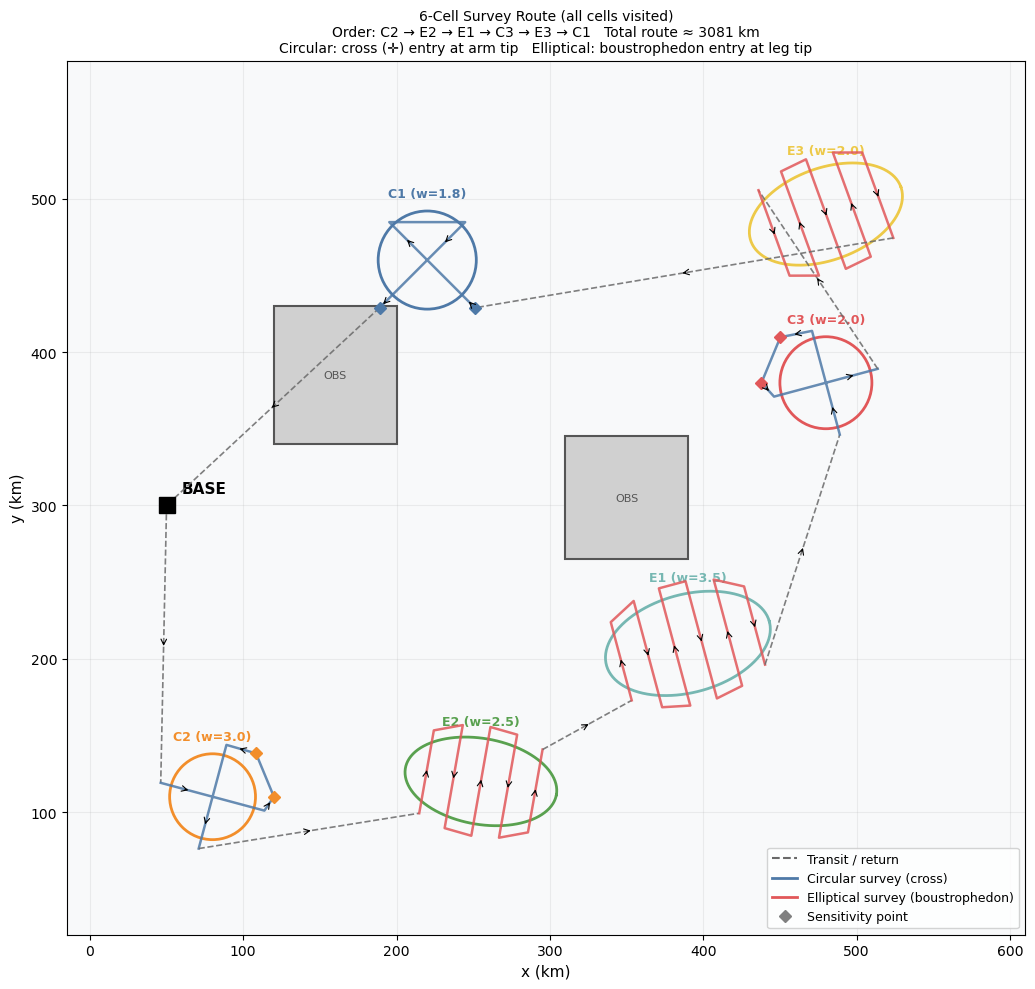

Visit order: C2 → E2 → E1 → C3 → E3 → C1
Total route distance: 3080.8 km
Route figure saved → figures/orienteering_route.png


In [8]:
# ── Route visualization: correct cross + boustrophedon patterns ──────────
# route_circ_wpts / route_ellip_wpts each return:
#   (dist, transit_wpts, survey_wpts, exit_pt)
# transit_wpts : obstacle-avoiding path from current pos to survey entry point  → drawn DASHED
# survey_wpts  : actual survey path starting at entry point                     → drawn SOLID
# No pre-transit to cell.center; aircraft enters directly at the arm / leg tip.

def route_circ_wpts(start, cell, theta, L, all_obs):
    """Same as route_circ_from but returns waypoints for visualization.
    transit_wpts: start -> first task entry (drawn dashed)
    survey_wpts: from first task entry onward (drawn solid)
    Returns (dist, transit_wpts, survey_wpts, exit_pt)."""
    s = np.asarray(start, float)
    P0, P1, P2, P3 = cell.cross_endpoints(theta, L)
    c = np.asarray(cell.center, float)
    arm1 = [(P0, [c, P1], P1), (P1, [c, P0], P0)]
    arm2 = [(P2, [c, P3], P3), (P3, [c, P2], P2)]
    task_opts = [arm1, arm2] + [[(sp, [], sp)] for sp in cell.sensitivity_points]
    n = len(task_opts)
    best_d, best_pos = float('inf'), s
    best_tr, best_survey = [s], [s]
    for perm in itertools.permutations(range(n)):
        for choices in itertools.product(*[task_opts[i] for i in perm]):
            pos = s.copy(); d = 0.; first_tr = None; surv = []
            for ti, (entry, wpts, exit_pt) in enumerate(choices):
                entry = np.asarray(entry, float)
                seg = [np.asarray(p, float) for p in multi_obs(pos, entry, all_obs)]
                d += path_len(seg)
                if ti == 0:
                    first_tr = seg; surv = [seg[-1]]
                else:
                    surv.extend(seg[1:])
                pos = seg[-1]
                for wp in wpts:
                    wp = np.asarray(wp, float); d += np.linalg.norm(wp - pos)
                    surv.append(wp); pos = wp
                pos = np.asarray(exit_pt, float)
            if d < best_d:
                best_d, best_pos = d, pos.copy()
                best_tr, best_survey = first_tr or [s], surv
    return best_d, best_tr, best_survey, best_pos

def route_ellip_wpts(start, cell, n, s, dt, rev, etop, all_obs):
    """Transit start → first leg entry point (dashed).
    Survey: all boustrophedon scan legs (solid).
    Returns (dist, transit_wpts, survey_wpts, exit_pt)."""
    s_ = np.asarray(start, float)
    ordered = list(reversed(cell.leg_positions(n, s))) if rev else cell.leg_positions(n, s)
    legs = []
    for xp in ordered:
        ep = cell.leg_endpoints(xp, dt)
        if ep is None: return float('inf'), [s_], [s_], s_
        legs.append(ep)
    dist = 0.; pos = s_.copy(); tr_wpts = None; survey_wpts = []
    for i, (bot, top) in enumerate(legs):
        gu = (i % 2 == 0) != etop; ep_, ex = (bot, top) if gu else (top, bot)
        seg = [np.asarray(p,float) for p in multi_obs(pos, ep_, all_obs)]
        dist += path_len(seg)
        if i == 0:
            tr_wpts = seg                       # transit = start → first leg entry
            survey_wpts = [seg[-1].copy()]      # survey starts at first leg entry
        else:
            survey_wpts.extend(seg[1:])         # inter-leg routing (obstacle-aware)
        pos = seg[-1]
        dist += np.linalg.norm(np.asarray(ex,float) - pos)
        survey_wpts.append(np.asarray(ex, float)); pos = np.asarray(ex, float)
    return dist, tr_wpts or [s_], survey_wpts, pos

# ── NN visit order through all 6 cells ───────────────────────────────────
def nn_order(start_node, cell_nodes, T_mat):
    remaining = list(cell_nodes); cur = start_node; order = []
    while remaining:
        nxt = min(remaining, key=lambda k: T_mat[cur, k])
        order.append(nxt); cur = nxt; remaining.remove(nxt)
    return order

visit_order = nn_order(0, valid_cells, T)

# ── Build route: no pre-transit to center; enter directly at arm/leg tip ─
pos = BASE.copy(); seg_wpts = []
for k in visit_order:
    cell = ALL_CELLS[k-1]
    cfg  = cell_configs[k-1][best_cfg_idx[k]]
    if isinstance(cell, CircularSupercell):
        theta = cfg['params']['theta']; L = cfg['params']['L']
        d, tr_wpts, sur_wpts, pos = route_circ_wpts(pos, cell, theta, L, OBSTACLES)
        col = '#4e79a7'
    else:
        n_, s__ = cfg['params']['n'], cfg['params']['s']
        rev, etop = cfg['params']['rev'], cfg['params']['etop']
        d, tr_wpts, sur_wpts, pos = route_ellip_wpts(pos, cell, n_, s__, DT, rev, etop, OBSTACLES)
        col = '#e15759'
    seg_wpts.append((np.array(tr_wpts), 'dimgray', 'transit', '--'))
    seg_wpts.append((np.array(sur_wpts), col, labels[k], '-'))
# Return to BASE
ret = [np.asarray(p,float) for p in multi_obs(pos, BASE, OBSTACLES)]
seg_wpts.append((np.array(ret), 'dimgray', 'return', '--'))

# ── Draw ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 10))
ax.set_facecolor('#f8f9fa')

for obs in OBSTACLES:
    ax.add_patch(plt.Polygon(obs, closed=True, facecolor='#d0d0d0', edgecolor='#555', lw=1.5, zorder=2))
    cx = np.mean([p[0] for p in obs]); cy = np.mean([p[1] for p in obs])
    ax.text(cx, cy, 'OBS', ha='center', va='center', fontsize=8, color='#555')

cell_colors = {'C1':'#4e79a7','C2':'#f28e2b','C3':'#e15759',
               'E1':'#76b7b2','E2':'#59a14f','E3':'#edc948'}
for k, cell in enumerate(ALL_CELLS):
    col = cell_colors[labels[k+1]]
    if isinstance(cell, CircularSupercell):
        ax.add_patch(plt.Circle(cell.center, cell.radius,
                                fill=False, edgecolor=col, lw=2, zorder=3))
        ax.text(cell.center[0], cell.center[1]+cell.radius+7,
                f'{cell.name} (w={cell.weight})', ha='center', va='bottom',
                fontsize=9, fontweight='bold', color=col)
        for sp in cell.sensitivity_points:
            ax.plot(*sp, 'D', color=col, ms=6, zorder=5)
    else:
        th = np.linspace(0, 2*pi, 200)
        R_ = np.array([[cos(cell.phi),-sin(cell.phi)],[sin(cell.phi),cos(cell.phi)]])
        pts = (R_ @ np.vstack([cell.a*np.cos(th), cell.b*np.sin(th)])).T + cell.center
        ax.plot(pts[:,0], pts[:,1], color=col, lw=2, zorder=3)
        ax.text(cell.center[0], cell.center[1]+cell.b+7,
                f'{cell.name} (w={cell.weight})', ha='center', va='bottom',
                fontsize=9, fontweight='bold', color=col)

for wpts, col, lbl, ls in seg_wpts:
    if len(wpts) >= 2:
        ax.plot(wpts[:,0], wpts[:,1], color=col,
                lw=1.2 if ls=='--' else 1.8, ls=ls, zorder=4, alpha=0.85)

# Direction arrows
all_wpts = np.vstack([s[0] for s in seg_wpts if len(s[0]) >= 2])
step = max(1, len(all_wpts) // 25)
for i in range(0, len(all_wpts)-1, step):
    p1, p2 = all_wpts[i], all_wpts[i+1]; dv = p2-p1; n = np.linalg.norm(dv)
    if n > 2:
        mid = (p1+p2)/2
        ax.annotate('', xy=mid+dv/n*3, xytext=mid-dv/n*3,
                    arrowprops=dict(arrowstyle='->', color='black', lw=0.8), zorder=6)

ax.plot(*BASE, 's', color='black', ms=11, zorder=7)
ax.text(BASE[0]+10, BASE[1]+8, 'BASE', fontsize=11, fontweight='bold')

order_str = ' \u2192 '.join(labels[k] for k in visit_order)
total_d = sum(path_len(s[0]) for s in seg_wpts if len(s[0]) >= 2)
ax.set_xlim(-15, 610); ax.set_ylim(20, 590); ax.set_aspect('equal')
ax.grid(True, alpha=0.2)
ax.set_xlabel('x (km)', fontsize=11); ax.set_ylabel('y (km)', fontsize=11)
ax.set_title(
    f'6-Cell Survey Route (all cells visited)\n'
    f'Order: {order_str}   Total route \u2248 {total_d:.0f} km\n'
    f'Circular: cross (\u271b) entry at arm tip   '
    f'Elliptical: boustrophedon entry at leg tip', fontsize=10)

import matplotlib.lines as mlines
handles = [
    mlines.Line2D([],[],color='dimgray',ls='--',lw=1.5,label='Transit / return'),
    mlines.Line2D([],[],color='#4e79a7',ls='-',lw=2,label='Circular survey (cross)'),
    mlines.Line2D([],[],color='#e15759',ls='-',lw=2,label='Elliptical survey (boustrophedon)'),
    mlines.Line2D([],[],marker='D',color='gray',ls='none',ms=6,label='Sensitivity point')]
ax.legend(handles=handles, loc='lower right', fontsize=9, framealpha=0.85)
plt.tight_layout()
plt.savefig('figures/orienteering_route.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()
print(f'Visit order: {order_str}')
print(f'Total route distance: {total_d:.1f} km')
print('Route figure saved \u2192 figures/orienteering_route.png')


In [9]:
# ── MILP: Orienteering Problem with MTZ subtour elimination ─────────────
# Variables: x[i,j] ∈ {0,1} arcs, y[k] ∈ {0,1} visits, u[k] ∈ [1,N] MTZ positions
# Objective: max Σ score_k · y_k
# Constraints:
#   (1) Σ_j x[0,j] = 1  (depart BASE once)
#   (2) Σ_i x[i,0] = 1  (return BASE once)
#   (3) Σ_j x[k,j] = y[k]  and  Σ_i x[i,k] = y[k]  ∀k   (flow conservation)
#   (4) Σ T[i,j]·x[i,j] + Σ sdist_k·y_k ≤ BUDGET   (flight budget)
#   (5) u[i] - u[j] + N·x[i,j] ≤ N-1  ∀i,j≠0       (MTZ subtour elimination)

def solve_op_milp(N, scores, sdist, T_mat, budget):
    n_nodes = N + 1
    arc_ids = [(i,j) for i in range(n_nodes) for j in range(n_nodes) if i!=j]
    n_arcs = len(arc_ids)
    arc_idx = {ij: idx for idx, ij in enumerate(arc_ids)}
    col_y = lambda k: n_arcs + (k-1)
    col_u = lambda k: n_arcs + N + (k-1)
    n_vars = n_arcs + N + N

    c_vec = np.zeros(n_vars)
    for k in range(1, N+1): c_vec[col_y(k)] = -scores[k-1]

    lb = np.zeros(n_vars); ub = np.ones(n_vars)
    for k in range(1, N+1): lb[col_u(k)] = 1.; ub[col_u(k)] = float(N)
    integ = np.ones(n_vars, int)
    for k in range(1, N+1): integ[col_u(k)] = 0  # u is continuous

    rows, lbs_c, ubs_c = [], [], []

    # (1) BASE departs once
    r = np.zeros(n_vars)
    for j in range(1, n_nodes): r[arc_idx[(0,j)]] = 1.
    rows.append(r); lbs_c.append(1.); ubs_c.append(1.)
    # (2) BASE receives once
    r = np.zeros(n_vars)
    for i in range(1, n_nodes): r[arc_idx[(i,0)]] = 1.
    rows.append(r); lbs_c.append(1.); ubs_c.append(1.)
    # (3) Flow conservation
    for k in range(1, N+1):
        for sign in [(1, 0), (0, 1)]:
            r = np.zeros(n_vars)
            for j in range(n_nodes):
                if j != k:
                    if sign[0]: r[arc_idx[(k,j)]] = 1.
                    else: r[arc_idx[(j,k)]] = 1.
            r[col_y(k)] = -1.
            rows.append(r); lbs_c.append(0.); ubs_c.append(0.)
    # (4) Budget
    r = np.zeros(n_vars)
    for (i,j), idx in arc_idx.items(): r[idx] = T_mat[i,j]
    for k in range(1, N+1): r[col_y(k)] += sdist[k-1]
    rows.append(r); lbs_c.append(-np.inf); ubs_c.append(budget)
    # (5) MTZ
    for k in range(1, N+1):
        for l in range(1, N+1):
            if k == l: continue
            r = np.zeros(n_vars)
            r[col_u(k)] = 1.; r[col_u(l)] = -1.; r[arc_idx[(k,l)]] = float(N)
            rows.append(r); lbs_c.append(-np.inf); ubs_c.append(float(N)-1.)

    A = csr_matrix(np.array(rows))
    t0 = time.time()
    res = sp_milp(c_vec, constraints=LinearConstraint(A, lbs_c, ubs_c),
                  integrality=integ, bounds=Bounds(lb=lb, ub=ub))
    t_solve = time.time() - t0
    if res.status != 0: return None, t_solve

    tour = [0]
    while True:
        cur = tour[-1]
        nxt = next((j for j in range(n_nodes)
                    if j != cur and res.x[arc_idx[(cur,j)]] > 0.5), None)
        if nxt is None or nxt == 0: break
        tour.append(nxt)
    tour_cells = [k for k in tour if k != 0]
    total_score = float(sum(scores[k-1] for k in tour_cells))
    total_dist = (sum(T_mat[tour[i], tour[i+1]] for i in range(len(tour)-1))
                  + T_mat[tour[-1], 0] + sum(sdist[k-1] for k in tour_cells))
    return dict(tour=tour_cells, score=total_score, dist=total_dist), t_solve

milp_sol, t_milp = solve_op_milp(N_CELLS, scores_vec, sdist_vec, T, BUDGET)

print('='*60)
print('MILP  (OP with MTZ subtour elimination, HiGHS backend)')
print('='*60)
if milp_sol:
    tstr = ' → '.join(labels[k] for k in milp_sol['tour'])
    ok = abs(milp_sol['score'] - global_opt[2]) < 1e-4
    print(f'  Tour   : {tstr}')
    print(f'  Score  : {milp_sol["score"]:.4f}   Dist : {milp_sol["dist"]:.1f} km')
    print(f'  Time   : {t_milp*1000:.1f} ms  |  vars: {N_CELLS*(N_CELLS+1)} binary + {N_CELLS} continuous')
    print(f'  Matches global optimum: {ok}')
    assert ok, 'MILP failed to recover global optimum!'
    print('  MILP ✓')


MILP  (OP with MTZ subtour elimination, HiGHS backend)
  Tour   : C2 → E2 → E1 → C3
  Score  : 12.1182   Dist : 2629.7 km
  Time   : 12.1 ms  |  vars: 42 binary + 6 continuous
  Matches global optimum: True
  MILP ✓


In [10]:
# ── ALNS: Adaptive Large Neighbourhood Search ───────────────────────────
# State: ordered list of visited cell indices (tour)
# Destroy operators:
#   D0  rm1+reinsert  : remove 1 random cell, greedily reinsert all unvisited by ratio
#   D1  swap_unvisited: swap one visited cell with one random unvisited cell
#   D2  2-opt         : reverse a random subsequence of the tour
#   D3  rm2+reinsert  : remove 2 random cells, greedily reinsert
# Repair: greedy best-position insertion (maximise score/cost ratio)
# Adaptive weights: improvement → ×1.2, decay ×0.98/iter, clipped [0.1, 10]

def insert_delta(tour_list, k, pos):
    prev = tour_list[pos-1] if pos > 0 else 0
    nxt  = tour_list[pos]   if pos < len(tour_list) else 0
    return T[prev,k] + sdist_vec[k-1] + T[k,nxt] - T[prev, nxt if pos < len(tour_list) else 0]

def alns_op(n_iter=1000, seed=42, random_init=False):
    rng = np.random.RandomState(seed)

    if random_init:
        tour = []
        for k in rng.permutation(valid_cells).tolist():
            pos = rng.randint(len(tour)+1)
            d_try, _ = tour_dist_score(tour[:pos]+[k]+tour[pos:])
            if d_try <= BUDGET: tour.insert(pos, k)
    else:
        tour = []; remaining = set(valid_cells); cur_d = 0.
        while remaining:
            best_r, best_k, best_pos = -1., None, None
            for k in remaining:
                for pos in range(len(tour)+1):
                    delta = insert_delta(tour, k, pos)
                    if cur_d + delta <= BUDGET:
                        ratio = scores_vec[k-1] / (delta + 1e-9)
                        if ratio > best_r: best_r, best_k, best_pos = ratio, k, pos
            if best_k is None: break
            tour.insert(best_pos, best_k); remaining.discard(best_k)
            cur_d, _ = tour_dist_score(tour)

    best_tour = tour[:]
    best_d, best_s = tour_dist_score(best_tour)
    hist = [best_s]
    n_ops = 4; w = np.ones(n_ops); op_imps = np.zeros(n_ops, int)

    for _ in range(n_iter):
        op = rng.choice(n_ops, p=w/w.sum())
        new_tour = tour[:]
        visited_set = set(new_tour)
        unvisited = [k for k in valid_cells if k not in visited_set]

        if op == 0 and new_tour:   # rm1 + reinsert
            rm_pos = rng.randint(len(new_tour))
            rm_k   = new_tour.pop(rm_pos)
            in_t   = set(new_tour)
            unv    = [rm_k] + [k for k in valid_cells if k not in in_t and k != rm_k]
            for k in sorted(unv, key=lambda x: -scores_vec[x-1]):
                nd, _ = tour_dist_score(new_tour)
                bp = min(range(len(new_tour)+1), key=lambda p: insert_delta(new_tour, k, p))
                if nd + insert_delta(new_tour, k, bp) <= BUDGET:
                    new_tour.insert(bp, k)
        elif op == 1 and unvisited and new_tour:  # swap
            rm_pos = rng.randint(len(new_tour)); new_tour.pop(rm_pos)
            add_k  = rng.choice(unvisited)
            nd, _  = tour_dist_score(new_tour)
            bp = min(range(len(new_tour)+1), key=lambda p: insert_delta(new_tour, add_k, p))
            if nd + insert_delta(new_tour, add_k, bp) <= BUDGET:
                new_tour.insert(bp, add_k)
        elif op == 2 and len(new_tour) >= 2:  # 2-opt
            i = rng.randint(len(new_tour)-1); j = rng.randint(i+1, len(new_tour))
            new_tour[i:j+1] = new_tour[i:j+1][::-1]
        elif op == 3 and len(new_tour) >= 2:  # rm2 + reinsert
            rp = sorted(rng.choice(len(new_tour), 2, replace=False), reverse=True)
            removed = [new_tour.pop(p) for p in rp]
            rm_set  = set(removed); in_t = set(new_tour)
            reins   = removed + [x for x in valid_cells if x not in in_t and x not in rm_set]
            for k in reins:
                nd, _ = tour_dist_score(new_tour)
                bp = min(range(len(new_tour)+1), key=lambda p: insert_delta(new_tour, k, p))
                if nd + insert_delta(new_tour, k, bp) <= BUDGET:
                    new_tour.insert(bp, k)

        nd, ns = tour_dist_score(new_tour)
        if nd <= BUDGET and (ns > best_s or (ns == best_s and nd < best_d)):
            best_tour = new_tour[:]; best_s = ns; best_d = nd
            op_imps[op] += 1; w[op] = min(w[op] * 1.2, 10.)
        if nd <= BUDGET: tour = new_tour[:]
        w *= 0.98; w = np.clip(w, 0.1, 10.)
        hist.append(best_s)

    return best_tour, best_s, best_d, hist, op_imps


OP_NAMES = ['rm1+reinsert', 'swap_unvisited', '2-opt', 'rm2+reinsert']
alns_runs_rand = []; alns_runs_greedy = []

print('='*60)
print('ALNS  (1000 iterations)')
print('='*60)
print('  Random initialisation (10 seeds):')
for seed in range(10):
    t0 = time.time()
    bt, bs, bd, hist, imps = alns_op(n_iter=1000, seed=seed, random_init=True)
    t_a = time.time() - t0
    ok  = abs(bs - global_opt[2]) < 1e-4
    alns_runs_rand.append((bt, bs, bd, hist, imps, t_a, ok))
    tstr = ' → '.join(labels[k] for k in bt)
    print(f'    Seed {seed}: score={bs:.4f}  dist={bd:.1f}km  '
          f'n_imps={int(imps.sum())}  time={t_a*1000:.0f}ms  match={ok}')
    print(f'             [{tstr}]')

n_r = sum(1 for *_,ok in alns_runs_rand if ok)
print(f'\n  Random init: {n_r}/{len(alns_runs_rand)} seeds matched global optimum.')

print('\n  Greedy initialisation (5 seeds):')
for seed in range(5):
    t0 = time.time()
    bt, bs, bd, hist, imps = alns_op(n_iter=500, seed=seed, random_init=False)
    t_a = time.time() - t0
    ok  = abs(bs - global_opt[2]) < 1e-4
    alns_runs_greedy.append((bt, bs, bd, hist, imps, t_a, ok))
    tstr = ' → '.join(labels[k] for k in bt)
    print(f'    Seed {seed}: score={bs:.4f}  dist={bd:.1f}km  n_imps={int(imps.sum())}  match={ok}  [{tstr}]')

n_g = sum(1 for *_,ok in alns_runs_greedy if ok)
assert n_r == len(alns_runs_rand), f'Only {n_r}/10 random seeds found global opt'
assert n_g == len(alns_runs_greedy), f'Only {n_g}/5 greedy seeds found global opt'
print(f'\nALNS ✓  All seeds found global optimum.')


ALNS  (1000 iterations)
  Random initialisation (10 seeds):
    Seed 0: score=12.1182  dist=2629.7km  n_imps=1  time=66ms  match=True
             [C3 → E1 → E2 → C2]


    Seed 1: score=12.1182  dist=2629.7km  n_imps=2  time=64ms  match=True
             [C2 → E2 → E1 → C3]


    Seed 2: score=12.1182  dist=2629.7km  n_imps=1  time=62ms  match=True
             [C2 → E2 → E1 → C3]
    Seed 3: score=12.1182  dist=2629.7km  n_imps=2  time=60ms  match=True
             [C3 → E1 → E2 → C2]
    Seed 4: score=12.1182  dist=2629.7km  n_imps=2  time=62ms  match=True
             [C2 → E2 → E1 → C3]
    Seed 5: score=12.1182  dist=2629.7km  n_imps=1  time=63ms  match=True
             [C3 → E1 → E2 → C2]


    Seed 6: score=12.1182  dist=2629.7km  n_imps=2  time=63ms  match=True


             [C2 → E2 → E1 → C3]
    Seed 7: score=12.1182  dist=2629.7km  n_imps=3  time=60ms  match=True
             [C3 → E1 → E2 → C2]
    Seed 8: score=12.1182  dist=2629.7km  n_imps=5  time=61ms  match=True
             [C3 → E1 → E2 → C2]
    Seed 9: score=12.1182  dist=2629.7km  n_imps=2  time=61ms  match=True
             [C3 → E1 → E2 → C2]

  Random init: 10/10 seeds matched global optimum.

  Greedy initialisation (5 seeds):
    Seed 0: score=12.1182  dist=2629.7km  n_imps=1  match=True  [C3 → E1 → E2 → C2]
    Seed 1: score=12.1182  dist=2629.7km  n_imps=1  match=True  [C2 → E2 → E1 → C3]
    Seed 2: score=12.1182  dist=2629.7km  n_imps=1  match=True  [C2 → E2 → E1 → C3]
    Seed 3: score=12.1182  dist=2629.7km  n_imps=1  match=True  [C2 → E2 → E1 → C3]
    Seed 4: score=12.1182  dist=2629.7km  n_imps=1  match=True  [C2 → E2 → E1 → C3]

ALNS ✓  All seeds found global optimum.


ALGORITHM COMPARISON
Method                    Score     Dist                         Tour      Time   =Opt
------------------------------------------------------------------------
Exhaustive              12.1182   2629.7                  C2→E2→E1→C3      <1ms    YES
MILP (HiGHS)            12.1182   2629.7                  C2→E2→E1→C3   12.1 ms    YES
ALNS greedy s=0         12.1182   2629.7                  C3→E1→E2→C2   31.0 ms    YES
ALNS greedy s=1         12.1182   2629.7                  C2→E2→E1→C3   30.7 ms    YES
ALNS greedy s=2         12.1182   2629.7                  C2→E2→E1→C3   30.4 ms    YES
ALNS greedy s=3         12.1182   2629.7                  C2→E2→E1→C3   30.2 ms    YES
ALNS greedy s=4         12.1182   2629.7                  C2→E2→E1→C3   30.7 ms    YES
ALNS random s=0         12.1182   2629.7                  C3→E1→E2→C2   66.3 ms    YES
ALNS random s=1         12.1182   2629.7                  C2→E2→E1→C3   63.9 ms    YES
ALNS random s=2         12.1182   26

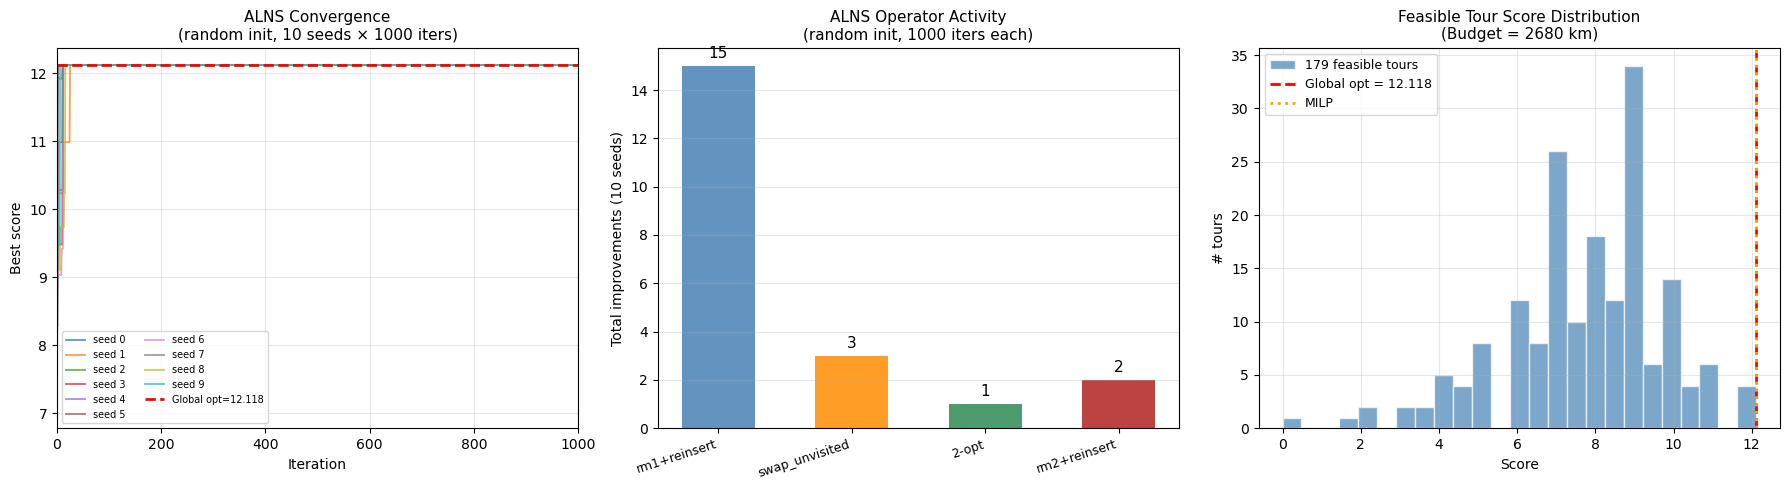

Figures saved.


In [11]:
# ── Comparison table + convergence figure ───────────────────────────────
tms = lambda s: f'{s*1000:.1f} ms' if s < 1 else f'{s:.2f} s'

print('='*72)
print('ALGORITHM COMPARISON')
print('='*72)
print(f"{'Method':<22} {'Score':>8} {'Dist':>8} {'Tour':>28} {'Time':>9} {'=Opt':>6}")
print('-'*72)
g_tstr = '→'.join(labels[k] for k in global_opt[0])
print(f"{'Exhaustive':22} {global_opt[2]:>8.4f} {global_opt[1]:>8.1f} {g_tstr:>28} {'<1ms':>9} {'YES':>6}")
if milp_sol:
    m_tstr = '→'.join(labels[k] for k in milp_sol['tour'])
    print(f"{'MILP (HiGHS)':22} {milp_sol['score']:>8.4f} {milp_sol['dist']:>8.1f} {m_tstr:>28} {tms(t_milp):>9} {'YES':>6}")
for sid, (bt, bs, bd, _, _, t_a, ok_a) in enumerate(alns_runs_greedy):
    tstr = '→'.join(labels[k] for k in bt)
    print(f"{'ALNS greedy s='+str(sid):22} {bs:>8.4f} {bd:>8.1f} {tstr:>28} {tms(t_a):>9} {('YES' if ok_a else 'NO'):>6}")
for sid, (bt, bs, bd, _, _, t_a, ok_a) in enumerate(alns_runs_rand):
    tstr = '→'.join(labels[k] for k in bt)
    print(f"{'ALNS random s='+str(sid):22} {bs:>8.4f} {bd:>8.1f} {tstr:>28} {tms(t_a):>9} {('YES' if ok_a else 'NO'):>6}")
print('='*72)

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: ALNS convergence (random init)
ax = axes[0]
colors = plt.cm.tab10(np.linspace(0, 0.9, 10))
for sid, (_, _, _, hist, _, _, _) in enumerate(alns_runs_rand):
    ax.plot(hist, lw=1.3, alpha=0.75, color=colors[sid], label=f'seed {sid}')
ax.axhline(global_opt[2], color='red', ls='--', lw=2, label=f'Global opt={global_opt[2]:.3f}')
ax.set_xlabel('Iteration'); ax.set_ylabel('Best score')
ax.set_title('ALNS Convergence\n(random init, 10 seeds × 1000 iters)', fontsize=11)
ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3); ax.set_xlim(0, 1000)

# Panel 2: Operator stats (total improvements, all random seeds)
ax = axes[1]
total_imps = sum(run[4] for run in alns_runs_rand)
x = np.arange(len(OP_NAMES)); width = 0.55
bars = ax.bar(x, total_imps, width,
              color=['steelblue','darkorange','seagreen','firebrick'], alpha=0.85)
for bar, val in zip(bars, total_imps):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            str(int(val)), ha='center', va='bottom', fontsize=11)
ax.set_xticks(x); ax.set_xticklabels(OP_NAMES, rotation=18, ha='right', fontsize=9)
ax.set_ylabel('Total improvements (10 seeds)')
ax.set_title('ALNS Operator Activity\n(random init, 1000 iters each)', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Panel 3: Score distribution
ax = axes[2]
feas_sc = [sc for _, d, sc in all_tours_data if d <= BUDGET]
ax.hist(feas_sc, bins=25, color='steelblue', alpha=0.7, edgecolor='white',
        label=f'{len(feas_sc)} feasible tours')
ax.axvline(global_opt[2], color='red', ls='--', lw=2,
           label=f'Global opt = {global_opt[2]:.3f}')
if milp_sol:
    ax.axvline(milp_sol['score'], color='orange', ls=':', lw=2, label='MILP')
ax.set_xlabel('Score'); ax.set_ylabel('# tours')
ax.set_title(f'Feasible Tour Score Distribution\n(Budget = {BUDGET:.0f} km)', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/orienteering_comparison.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()
print('Figures saved.')
